# Домашнее задание 3 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Загрузка датасета

In [2]:
df = pd.read_csv('train.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 891 строк, 12 столбцов


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Распределение значений признаков

Визуализируем распределения признаков `Survived`, `Pclass`, `Age`, `Sex`, `Parch`.

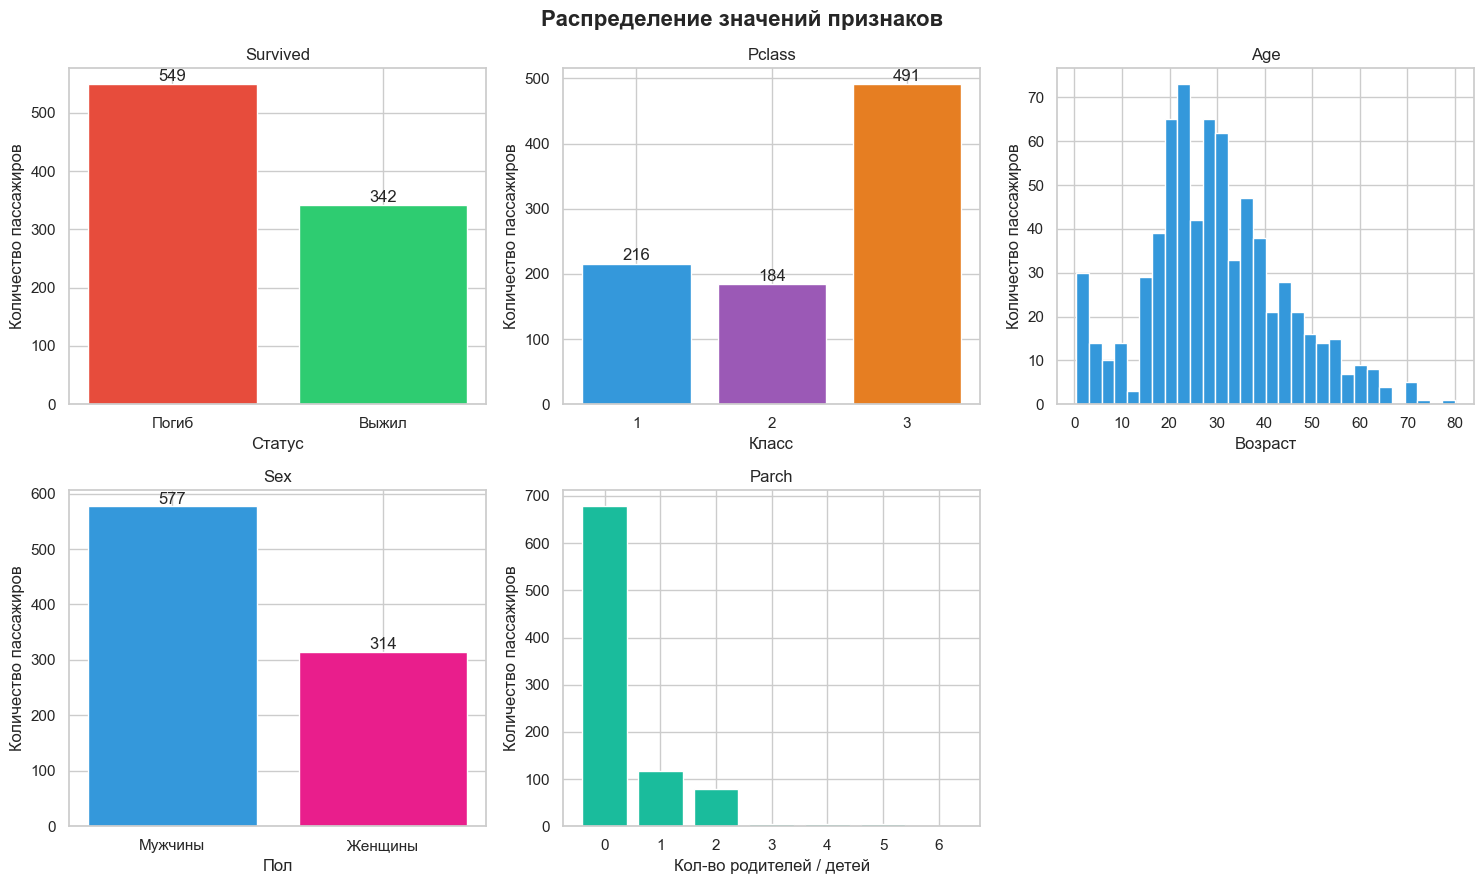

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Распределение значений признаков', fontsize=16, fontweight='bold')

survived_labels = {0: 'Погиб', 1: 'Выжил'}
survived_counts = df['Survived'].value_counts().rename(index=survived_labels)
axes[0, 0].bar(survived_counts.index, survived_counts.values, color=['#e74c3c', '#2ecc71'])
axes[0, 0].set_title('Survived')
axes[0, 0].set_xlabel('Статус')
axes[0, 0].set_ylabel('Количество пассажиров')
for i, v in enumerate(survived_counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha='center')

pclass_counts = df['Pclass'].value_counts().sort_index()
axes[0, 1].bar(pclass_counts.index.astype(str), pclass_counts.values, color=['#3498db', '#9b59b6', '#e67e22'])
axes[0, 1].set_title('Pclass')
axes[0, 1].set_xlabel('Класс')
axes[0, 1].set_ylabel('Количество пассажиров')
for i, v in enumerate(pclass_counts.values):
    axes[0, 1].text(i, v + 5, str(v), ha='center')

axes[0, 2].hist(df['Age'].dropna(), bins=30, color='#3498db', edgecolor='white')
axes[0, 2].set_title('Age')
axes[0, 2].set_xlabel('Возраст')
axes[0, 2].set_ylabel('Количество пассажиров')

sex_counts = df['Sex'].value_counts()
sex_labels = {'male': 'Мужчины', 'female': 'Женщины'}
sex_counts.index = sex_counts.index.map(sex_labels)
axes[1, 0].bar(sex_counts.index, sex_counts.values, color=['#3498db', '#e91e8c'])
axes[1, 0].set_title('Sex')
axes[1, 0].set_xlabel('Пол')
axes[1, 0].set_ylabel('Количество пассажиров')
for i, v in enumerate(sex_counts.values):
    axes[1, 0].text(i, v + 5, str(v), ha='center')

parch_counts = df['Parch'].value_counts().sort_index()
axes[1, 1].bar(parch_counts.index.astype(str), parch_counts.values, color='#1abc9c')
axes[1, 1].set_title('Parch')
axes[1, 1].set_xlabel('Кол-во родителей / детей')
axes[1, 1].set_ylabel('Количество пассажиров')

axes[1, 2].axis('off')  

plt.tight_layout()
plt.show()

## 3. Boxplot распределения возраста

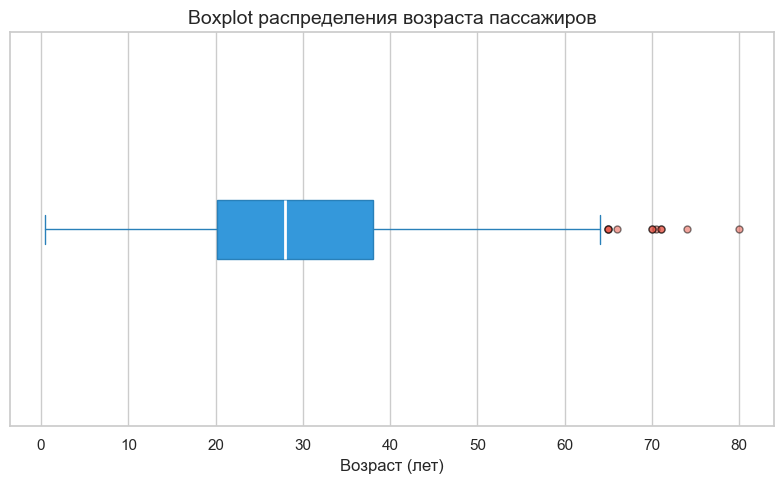

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df['Age'].dropna(), vert=False, patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='#2980b9'),
           medianprops=dict(color='white', linewidth=2),
           whiskerprops=dict(color='#2980b9'),
           capprops=dict(color='#2980b9'),
           flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=5, alpha=0.5))
ax.set_title('Boxplot распределения возраста пассажиров', fontsize=14)
ax.set_xlabel('Возраст (лет)')
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 4. Интерпретация boxplot

- **Медиана** (вертикальная белая линия) составляет около **28 лет** - половина пассажиров моложе, половина старше.
- **Межквартильный размах (IQR)**: ящик охватывает 25-75-й перцентили - примерно от **20 до 38 лет**. В этом диапазоне сосредоточена основная масса пассажиров.
- **Усы** (whiskers) протянуты до ~1 года и ~65 лет - это условная граница «нормальных» значений (1.5 × IQR от краёв ящика).
- **Выбросы** (красные точки) - пассажиры старше ~65 лет. Их немного; самому старому пассажиру 80 лет.
- **Вывод:** Большинство пассажиров Титаника - молодые взрослые (20-38 лет). Возраст распределён относительно симметрично с небольшим правым хвостом.

## 5. Pie chart для Survived и Pclass

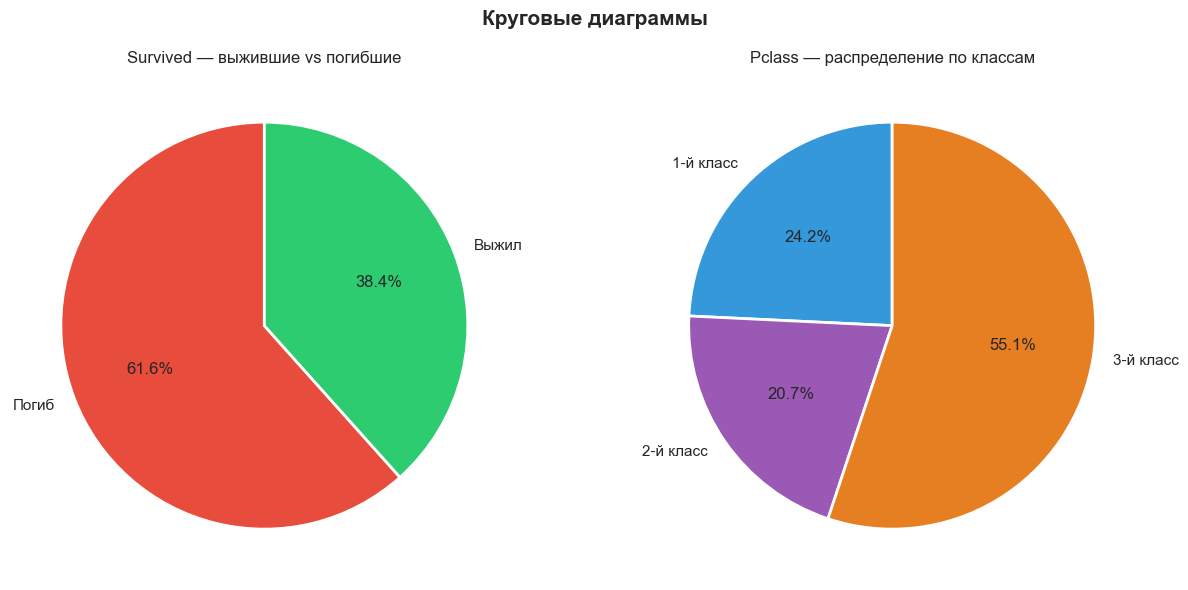

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Круговые диаграммы', fontsize=15, fontweight='bold')

survived_counts = df['Survived'].value_counts()
axes[0].pie(
    survived_counts.values,
    labels=['Погиб', 'Выжил'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Survived — выжившие vs погибшие')

pclass_counts = df['Pclass'].value_counts().sort_index()
axes[1].pie(
    pclass_counts.values,
    labels=['1-й класс', '2-й класс', '3-й класс'],
    autopct='%1.1f%%',
    colors=['#3498db', '#9b59b6', '#e67e22'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Pclass — распределение по классам')

plt.tight_layout()
plt.show()

## 6. Pairplot числовых признаков

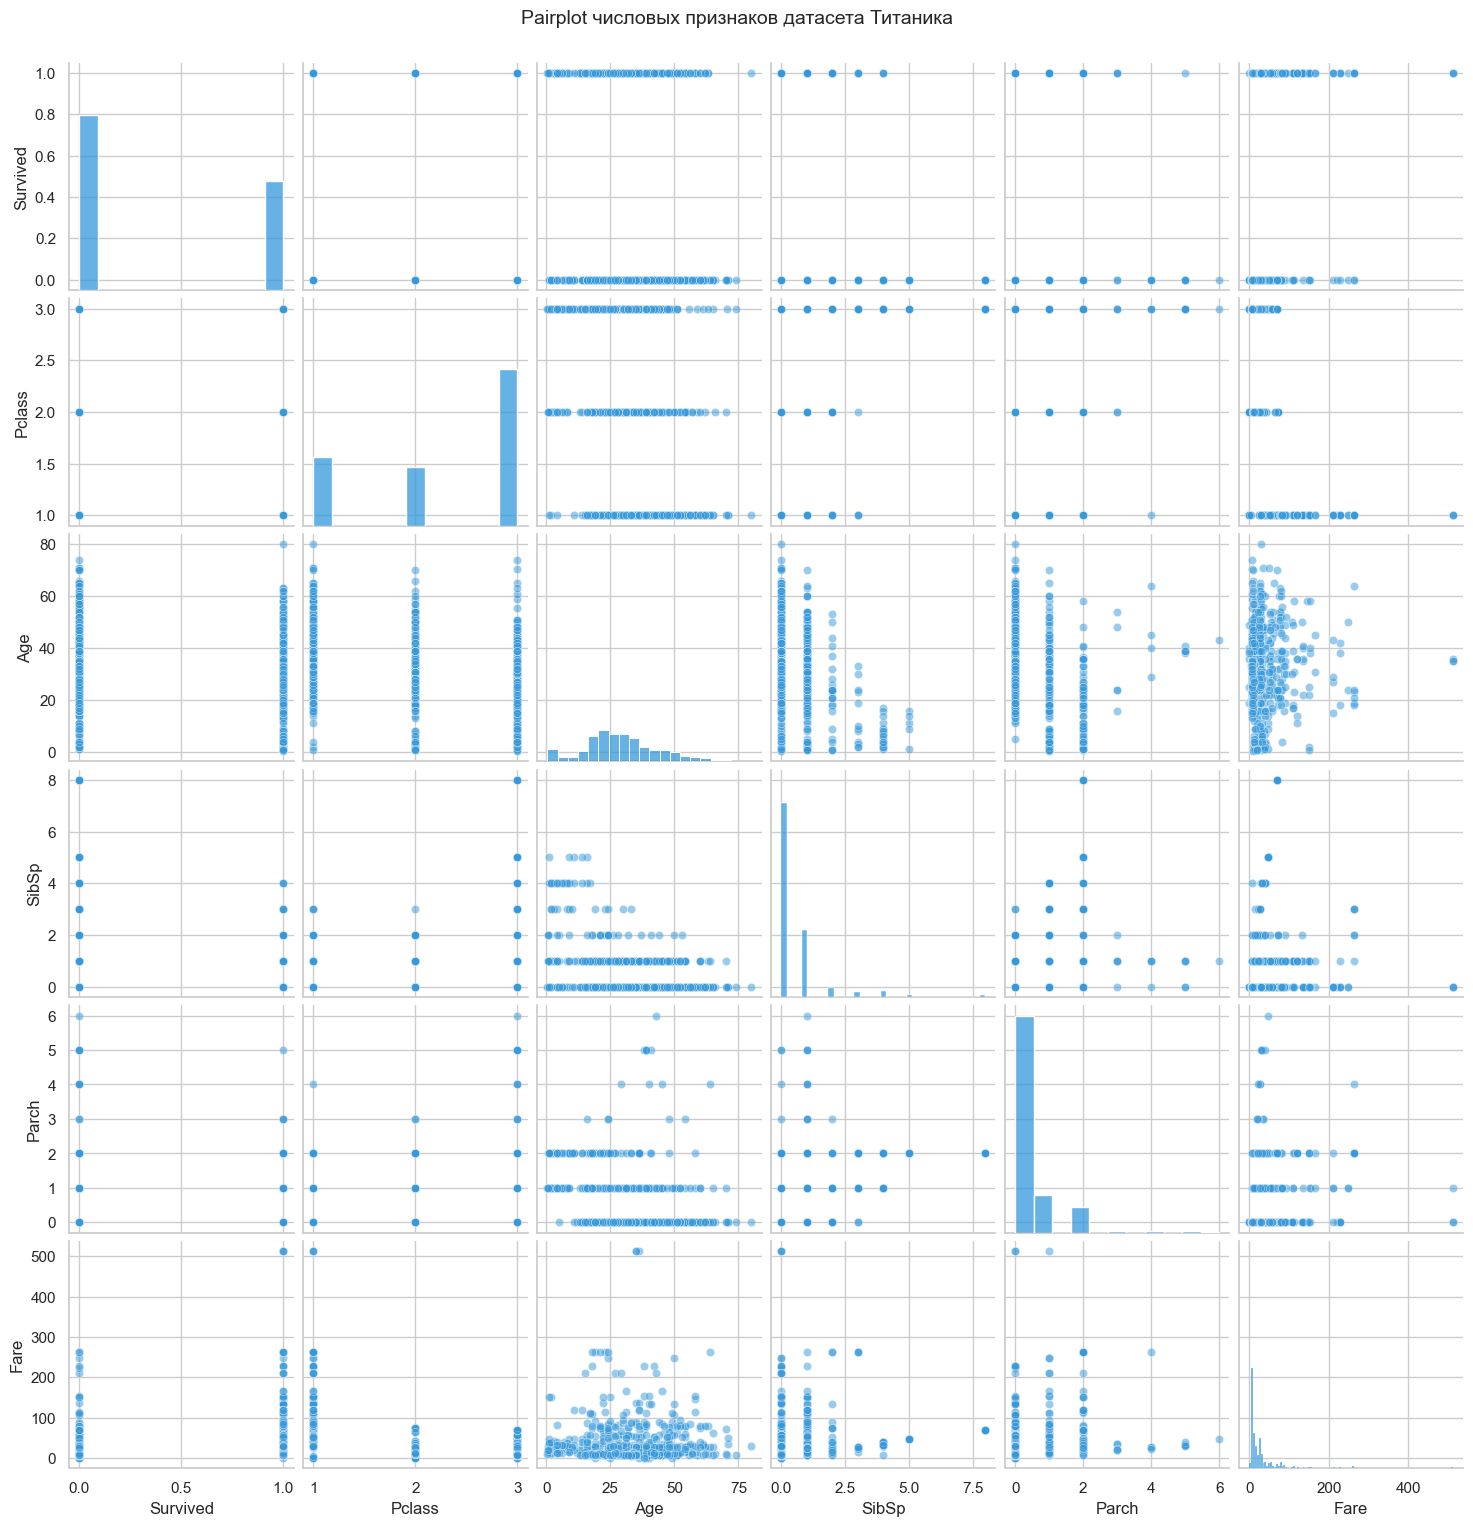

In [6]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
pair_df = df[numeric_cols].copy()

g = sns.pairplot(pair_df, hue=None, diag_kind='hist',
                 plot_kws={'alpha': 0.5, 'color': '#3498db'},
                 diag_kws={'color': '#3498db'})
g.figure.suptitle('Pairplot числовых признаков датасета Титаника', y=1.02, fontsize=14)
plt.show()

## 7. Violin plot: распределение возраста по полу

C:\Users\kapgo\AppData\Local\Temp\ipykernel_23364\385085068.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


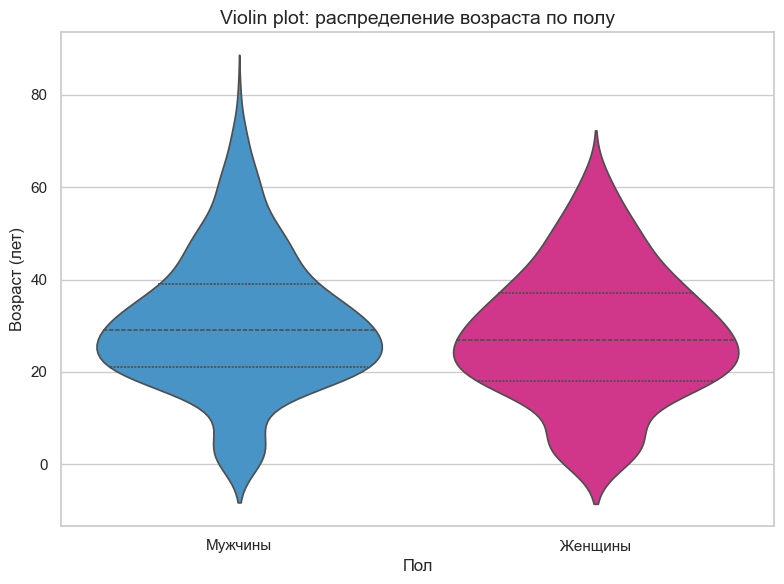

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_df = df[['Sex', 'Age']].dropna().copy()
plot_df['Sex_ru'] = plot_df['Sex'].map({'male': 'Мужчины', 'female': 'Женщины'})

sns.violinplot(
    data=plot_df,
    x='Sex_ru', y='Age',
    palette={'Мужчины': '#3498db', 'Женщины': '#e91e8c'},
    inner='quartile',
    ax=ax
)

ax.set_title('Violin plot: распределение возраста по полу', fontsize=14)
ax.set_xlabel('Пол')
ax.set_ylabel('Возраст (лет)')
plt.tight_layout()
plt.show()

## 8. Heatmap корреляционной матрицы

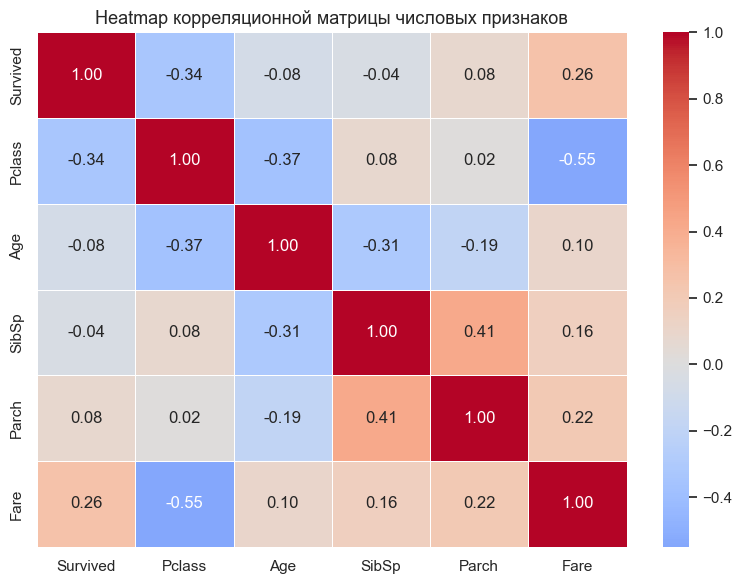

In [8]:
corr = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Heatmap корреляционной матрицы числовых признаков', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Интерактивный Sunburst plot (Plotly)

Первый уровень - количество пассажиров в каждом классе, второй - пол внутри класса.

In [9]:
sunburst_df = df.groupby(['Pclass', 'Sex']).size().reset_index(name='Count')
sunburst_df['Pclass_label'] = sunburst_df['Pclass'].map({1: '1-й класс', 2: '2-й класс', 3: '3-й класс'})
sunburst_df['Sex_label'] = sunburst_df['Sex'].map({'male': 'Мужчины', 'female': 'Женщины'})

fig = px.sunburst(
    sunburst_df,
    path=['Pclass_label', 'Sex_label'],
    values='Count',
    title='Распределение пассажиров по классу и полу',
    color='Pclass_label',
    color_discrete_map={
        '1-й класс': '#3498db',
        '2-й класс': '#9b59b6',
        '3-й класс': '#e67e22'
    }
)
fig.update_layout(
    margin=dict(t=50, l=0, r=0, b=0),
    title_font_size=16
)
fig.show()